# Digital Information Processing Lab 2025
---
<img align="left" src="https://www.cd.ovgu.de/cd_media/CD_OVGU/Downloads/Logo_jpg_png_svg_EPS_pdf/Logodownload/OVGU_Logo-download-1-p-1950.png" alt="drawing" width="350" />

### &emsp; Class 4: Filters
### &emsp; Group X : The teachers
### &emsp; 17.06.2025


---

Name | Mat. Nr. | Email
--------|---------|---------
Moinam Chatterjee | 193814 | moinam.chatterjee@ovgu.de
Behnam Ensan | 193714 | behnam.ensan@ovgu.de
Other Person | 123456 | email@ovgu.de

# Class 4: Filters


## Task: Filters

Get Acquainted:

* Familiarize yourself with the various filters and their parameters.

Choose Filters for ECG Signal:

* Select three filters to remove the three types of errors in the ECG signal *ecg_signal_all*.
* Explain which filter is suitable for each type of error and why.
* Set the filter parameters and demonstrate the before and after effects.
* Consider the order in which the filters should be applied.

Visualize the Filtering Process:

* Using the provided plot example, illustrate the filtering process of the ECG signal.
* Write a summary about the process


#Introduction: Parts of the ECG



The electrocardiogram (ECG) is a recording of the electrical activity of the heart. It consists of various components, each representing specific electrical activities of the heart:

* P wave: Shows atrial depolarization (spread of excitation in the atria).
* QRS complex: Shows ventricular depolarization (spread of excitation in the ventricles).
* T wave: Shows ventricular repolarization (recovery of excitation in the ventricles).
* U wave (if present): May represent late repolarization of the Purkinje fibers or other parts of the heart.

Here is an example of a clean ECG signal:



## ECG Generator

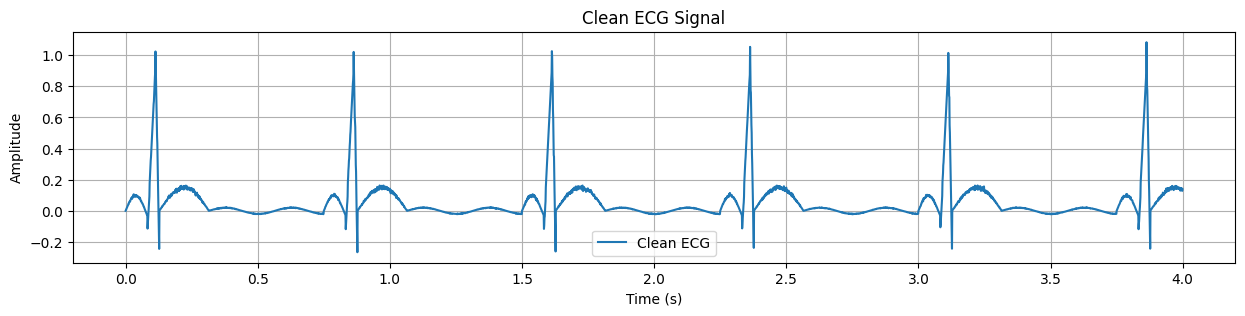

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def single_heartbeat(t, period, amplitude, seed=None):
    if seed is not None:
        np.random.seed(seed)
    amp_adj = 1 * np.random.normal(1, 0.05)
    time_adj1 = 1 * np.random.normal(1, 0.002)
    time_adj2 = 1 * np.random.normal(1, 0.002)
    time_adj3 = 1 * np.random.normal(1, 0.001)

    p_amp = amplitude * 0.1 * amp_adj
    p_wave = p_amp * np.sin(2 * np.pi * (t / period) * 5) * (t <= period * 0.12)

    qrs_start = period * 0.11 * time_adj1
    qrs_peak = period * 0.15 * time_adj2
    qrs_end = period * 0.17 * time_adj3
    qrs_complex = np.piecewise(t,
                               [t < qrs_start,
                                (t >= qrs_start) & (t < qrs_peak),
                                (t >= qrs_peak) & (t <= qrs_end),
                                t > qrs_end],
                               [0,
                                lambda t: amplitude * (-0.1 + (1.0 * (t - qrs_start) / (qrs_peak - qrs_start))),
                                lambda t: amplitude * amp_adj * (1.1 - (1.4 * (t - qrs_peak) / (qrs_end - qrs_peak))),
                                0])

    t_start = period * 0.17
    t_wave = amplitude * 0.15 * amp_adj * (np.sin(2 * np.pi * ((t - t_start) / period) * 2) * ((t >= t_start) & (t <= period * 0.42)))

    u_start = period * 0.42
    u_wave = amplitude * 0.02 * amp_adj * (np.sin(2 * np.pi * ((t - u_start) / period) * 3) * ((t >= u_start) & (t <= period * 1)))

    heartbeat = qrs_complex + p_wave + t_wave + u_wave
    return heartbeat

def generate_ecg_signal(bpm=60, duration=2, sampling_rate=500, amplitude=1):
    num_samples = int(duration * sampling_rate)
    t = np.linspace(0, duration, num_samples, endpoint=False)
    period = 60 / bpm
    ecg_signal = np.array([single_heartbeat(t_i % period, period, amplitude) for t_i in t])
    return t, ecg_signal

# Generate and plot ECG signal
bpm = 80
duration = 4
sampling_rate = 1000

t, ecg_signal = generate_ecg_signal(bpm=bpm, duration=duration, sampling_rate=sampling_rate)

plt.figure(figsize=(15, 3))
plt.plot(t, ecg_signal, label='Clean ECG')
plt.title('Clean ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()





# Introduction of Error Types



There are various types of disturbances that can affect an ECG signal. We will focus on three types:

* Gaussian noise: Random disturbances that make the signal noisy.
* Baseline wander: Slow fluctuations that change the baseline of the signal.
* 50 Hz power line interference: Disturbances from electrical devices that appear as a 50 Hz sine wave.




## Gaussian Noise

Gaussian noise is random disturbances that make the signal noisy.

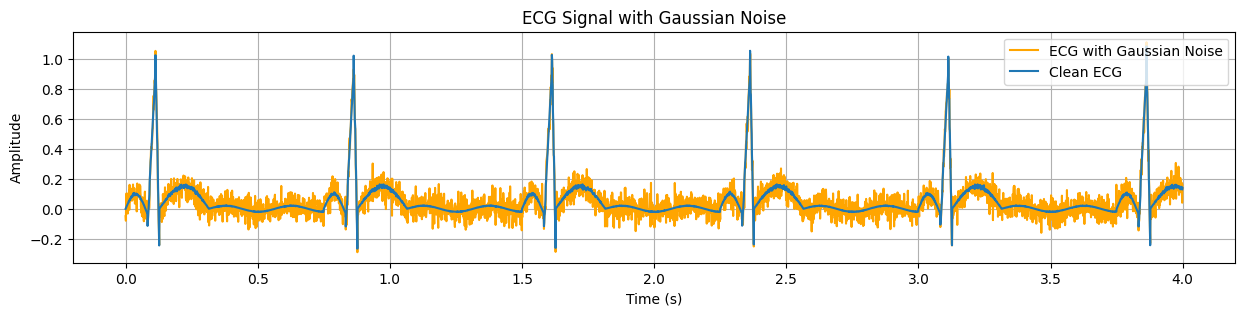

In [ ]:
# Function to add Gaussian noise
def add_gaussian_noise(ecg_signal, noise_level=0.01):
    noise = np.random.normal(0, noise_level, len(ecg_signal))
    ecg_signal_noisy = ecg_signal + noise
    return ecg_signal_noisy

# Add Gaussian noise and plot
ecg_signal_gaussian = add_gaussian_noise(ecg_signal, noise_level=0.05)

plt.figure(figsize=(15, 3))
plt.plot(t, ecg_signal_gaussian, label='ECG with Gaussian Noise', color='orange')
plt.plot(t, ecg_signal, label='Clean ECG')
plt.title('ECG Signal with Gaussian Noise')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

##Baseline Wander

Baseline wander are slow fluctuations that change the baseline of the signal.

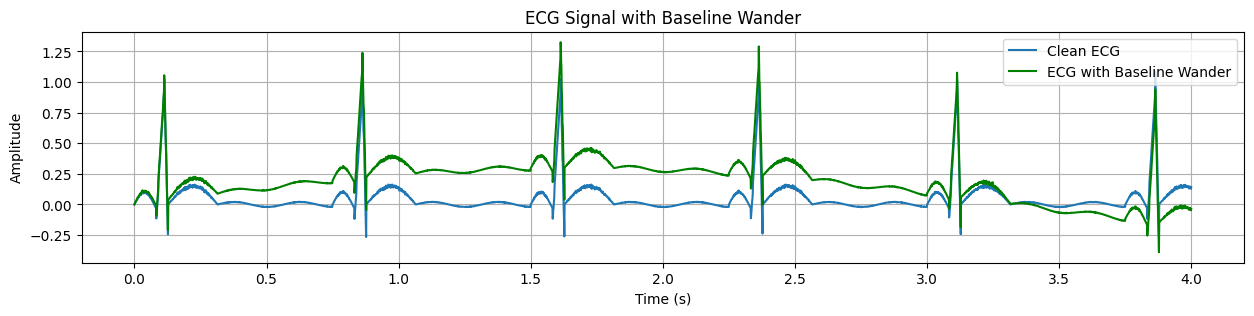

In [ ]:
# Function to add baseline wander
def add_baseline_wander(ecg_signal, wander_amplitude=0.1, wander_frequency=0.5, sampling_rate=500):
    t = np.linspace(0, len(ecg_signal) / sampling_rate, len(ecg_signal), endpoint=False)
    baseline_wander = wander_amplitude * np.sin(2 * np.pi * wander_frequency * t)
    ecg_signal_wander = ecg_signal + baseline_wander
    return ecg_signal_wander

# Add baseline wander and plot
ecg_signal_wander = add_baseline_wander(ecg_signal, wander_amplitude=0.3, wander_frequency=0.15, sampling_rate=sampling_rate)

plt.figure(figsize=(15, 3))
plt.plot(t, ecg_signal, label='Clean ECG')
plt.plot(t, ecg_signal_wander, label='ECG with Baseline Wander', color='green')
plt.title('ECG Signal with Baseline Wander')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

##50 Hz Power Line Interference

Power line interference are disturbances from electrical devices that appear as a 50 Hz sine wave.

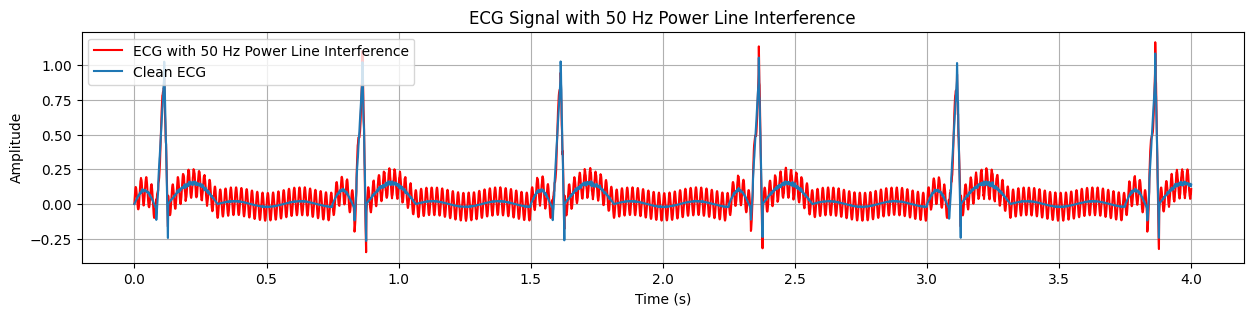

In [ ]:
# Function to add 50 Hz power line interference
def add_mains_hum(ecg_signal, hum_frequency=50, hum_amplitude=0.2, sampling_rate=500):
    t = np.linspace(0, len(ecg_signal) / sampling_rate, len(ecg_signal), endpoint=False)
    mains_hum = hum_amplitude * np.sin(2 * np.pi * hum_frequency * t)
    ecg_signal_hum = ecg_signal + mains_hum
    return ecg_signal_hum

# Add power line interference and plot
ecg_signal_hum = add_mains_hum(ecg_signal, hum_amplitude=0.1, sampling_rate=sampling_rate)

plt.figure(figsize=(15, 3))
plt.plot(t, ecg_signal_hum, label='ECG with 50 Hz Power Line Interference', color='red')
plt.plot(t, ecg_signal, label='Clean ECG')
plt.title('ECG Signal with 50 Hz Power Line Interference')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

##All Errors Combined

Now all error types will be applied to the clean signal and plotted.

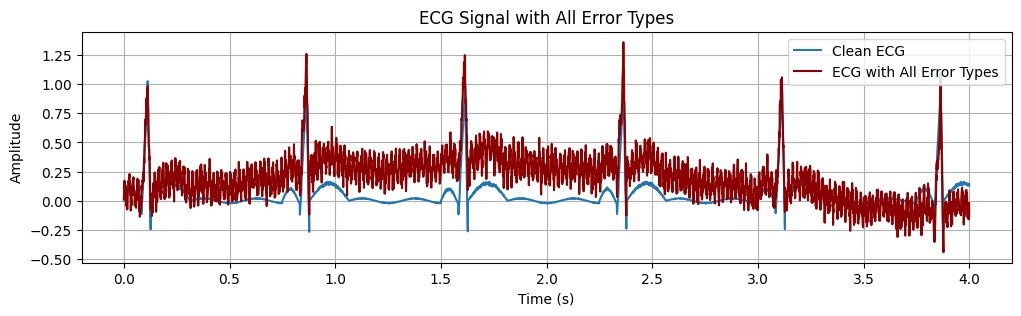

In [ ]:
# Add all error types
ecg_signal_all = add_gaussian_noise(ecg_signal, noise_level=0.05)
ecg_signal_all = add_baseline_wander(ecg_signal_all, wander_amplitude=0.3, wander_frequency=0.15, sampling_rate=sampling_rate)
ecg_signal_all = add_mains_hum(ecg_signal_all, hum_amplitude=0.1, sampling_rate=sampling_rate)

# Plot all error types
plt.figure(figsize=(12, 3))
plt.plot(t, ecg_signal, label='Clean ECG')
plt.plot(t, ecg_signal_all, label='ECG with All Error Types', color='darkred')
plt.title('ECG Signal with All Error Types')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# Filters

Here are some implementations of filters:



## High-pass filter

In [ ]:
from scipy.signal import butter, filtfilt, lfilter, iirnotch
import pywt
import ipywidgets as widgets
from ipywidgets import interact

# Function to apply a high-pass filter
def apply_highpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data)
    return y

### Example High-pass

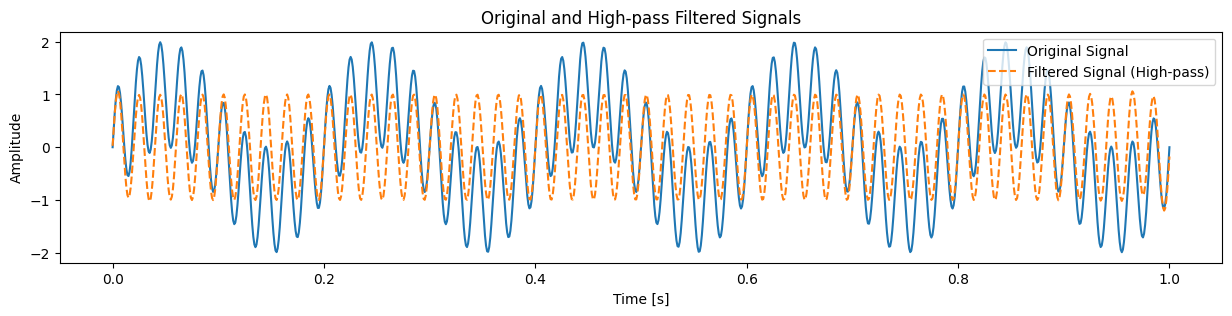

In [ ]:
fs = 1000
t2 = np.linspace(0, 1.0, fs)
signal = np.sin(2 * np.pi * 5 * t2) + np.sin(2 * np.pi * 50 * t2)
filtered_signal = apply_highpass_filter(signal, 20, fs)

plt.figure(figsize=(15, 3))
plt.plot(t2, signal, label='Original Signal')
plt.plot(t2, filtered_signal, label='Filtered Signal (High-pass)', linestyle='--')
plt.title('Original and High-pass Filtered Signals')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Notch Filter

A notch filter can be used to remove a specific frequency from a signal.

In [ ]:

# Function to apply a notch filter
def apply_notch_filter(data, cutoff, fs, quality_factor):
    b, a = iirnotch(cutoff, quality_factor, fs)
    return filtfilt(b, a, data)

### Example Notch Filter

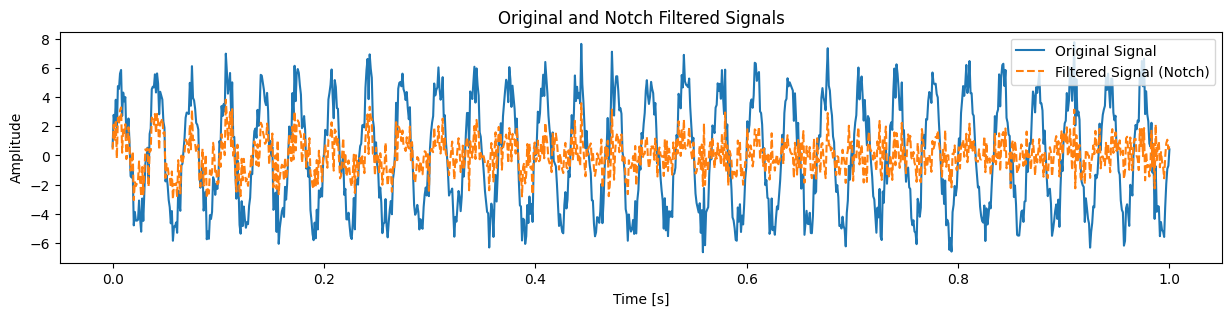

In [ ]:
# Create a random signal combined with a sine wave
np.random.seed(0)  # For reproducibility
random_signal = np.random.randn(len(t))
sine_signal = 5 * np.sin(2 * np.pi * 30 * t2)  # Sine wave with 30 Hz frequency
sine_signal_gaussian = add_gaussian_noise(sine_signal, noise_level=1)

# Apply notch filter
cutoff = 30  # Frequency to be removed from signal (notch frequency)
quality_factor = 30  # Quality factor of the notch filter
filtered_signal_notch = apply_notch_filter(sine_signal_gaussian, cutoff, fs, quality_factor)

# Plot the original and filtered signals
plt.figure(figsize=(15, 3))
plt.plot(t2, sine_signal_gaussian, label='Original Signal')
plt.plot(t2, filtered_signal_notch, label='Filtered Signal (Notch)', linestyle='--')
plt.title('Original and Notch Filtered Signals')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Wavelet-Denoising

Wavelet-Denoising can be used to remove high-frequency noise such as Gaussian noise while preserving important features of the signal.

In [ ]:
# Function to apply wavelet denoising
def apply_wavelet_denoising(data, wavelet='db4', level=1):
    coeffs = pywt.wavedec(data, wavelet, mode='per')
    sigma = np.median(np.abs(coeffs[-level])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(data)))
    coeffs[1:] = (pywt.threshold(i, value=uthresh, mode='soft') for i in coeffs[1:])
    return pywt.waverec(coeffs, wavelet, mode='per')

### Example Wavelet-Denoising

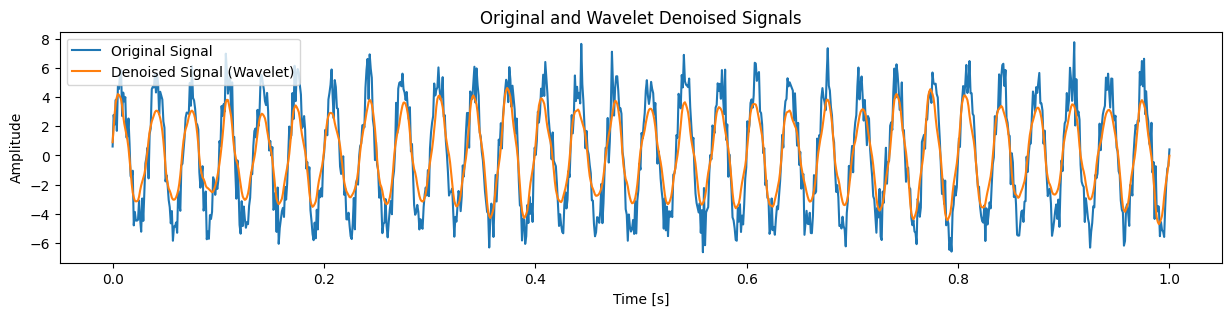

In [ ]:
# Apply wavelet denoising
denoised_signal_wavelet = apply_wavelet_denoising(sine_signal_gaussian, wavelet='db4', level=8)

# Plot the original and denoised signals
plt.figure(figsize=(15, 3))
plt.plot(t2, sine_signal_gaussian, label='Original Signal')
plt.plot(t2, denoised_signal_wavelet, label='Denoised Signal (Wavelet)')
plt.title('Original and Wavelet Denoised Signals')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Median Filter

A median filter can be used to remove impulse noise while preserving the edges of the signal.

In [ ]:
from scipy.signal import medfilt

# Function to apply a median filter
def apply_median_filter(data, kernel_size=3):
    return medfilt(data, kernel_size)

### Example Median

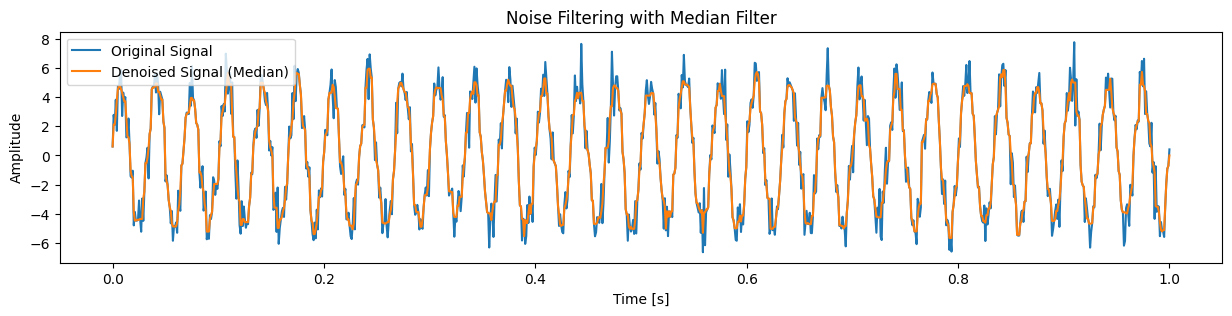

In [ ]:
# Apply denoising
denoised_signal_median = apply_median_filter(sine_signal_gaussian, kernel_size=5)

# Plot the original and denoised signals
plt.figure(figsize=(15, 3))
plt.plot(t2, sine_signal_gaussian, label='Original Signal')
plt.plot(t2, denoised_signal_median, label='Denoised Signal (Median)')
plt.title('Noise Filtering with Median Filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Moving Average Filter

A moving average filter can be used to smooth high-frequency noise by averaging over a window.

In [ ]:
# Function to apply a moving average filter
def apply_moving_average_filter(data, window_size=5):
    if window_size < 1:
        raise ValueError("Window size must be at least 1.")
    return np.convolve(data, np.ones(window_size) / window_size, mode='same')

### Example Moving Average

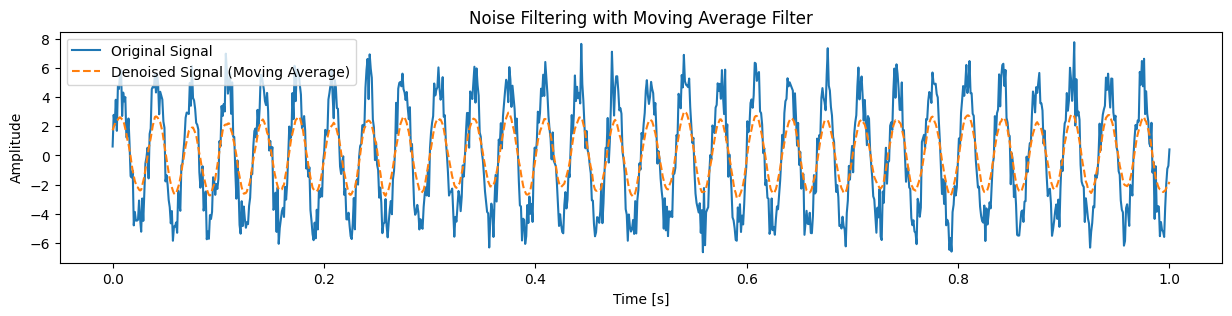

In [ ]:
# Apply moving average filter
denoised_signal_moving_average = apply_moving_average_filter(sine_signal_gaussian, window_size=20)

# Plot the original and denoised signals
plt.figure(figsize=(15, 3))
plt.plot(t2, sine_signal_gaussian, label='Original Signal')
plt.plot(t2, denoised_signal_moving_average, label='Denoised Signal (Moving Average)', linestyle='--')
plt.title('Noise Filtering with Moving Average Filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Fourier Transform Filter

A Fourier transform filter can be used to smooth high-frequency noise by transforming the signal into the frequency domain, removing unwanted frequencies, and transforming the signal back into the time domain.


In [ ]:
# Function to apply a Fourier transform filter
def apply_fourier_filter(data, cutoff):
    fft_data = np.fft.fft(data)
    frequencies = np.fft.fftfreq(len(data), d=1/sampling_rate)
    fft_data[np.abs(frequencies) > cutoff] = 0
    filtered_signal = np.fft.ifft(fft_data).real
    return filtered_signal

### Example Fourier Transform Filter

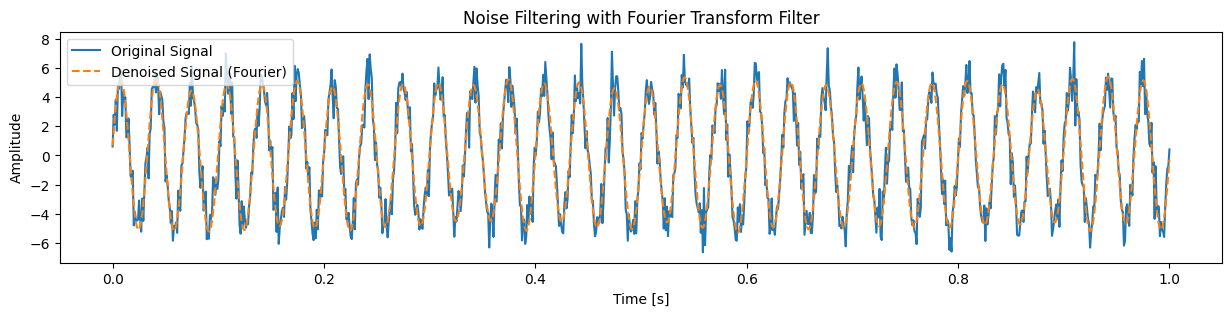

In [ ]:
# Apply Fourier transform filter
cutoff = 30 # Cutoff frequency
denoised_signal_fourier = apply_fourier_filter(sine_signal_gaussian, cutoff)

# Plot the original and denoised signals
plt.figure(figsize=(15, 3))
plt.plot(t2, sine_signal_gaussian, label='Original Signal')
plt.plot(t2, denoised_signal_fourier, label='Denoised Signal (Fourier)', linestyle='--')
plt.title('Noise Filtering with Fourier Transform Filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Savitzky-Golay Filter

A Savitzky-Golay filter can be used to smooth high-frequency noise while preserving important features of the signal. This filter is particularly good at preserving the signal integrity as it fits a polynomial to the data points and smooths them accordingly.


In [ ]:
from scipy.signal import savgol_filter

# Function to apply a Savitzky-Golay filter
def apply_savgol_filter(data, window_length=5, polyorder=2):
    return savgol_filter(data, window_length, polyorder)

### Example Savitzky-Golay Filter

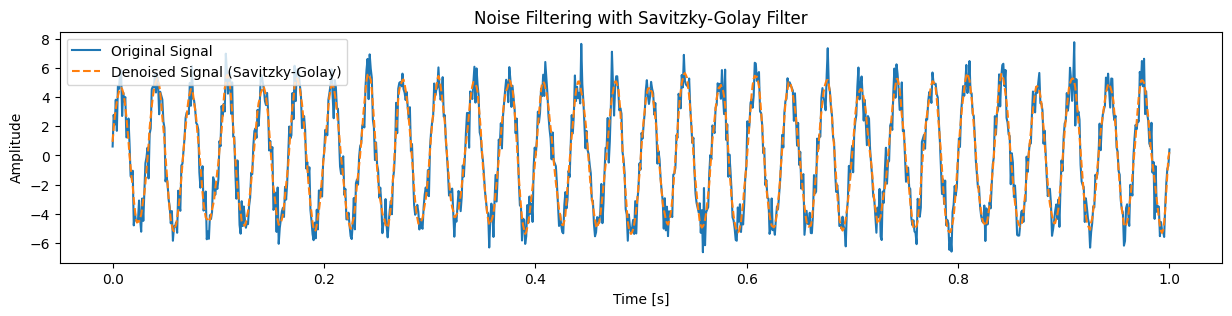

In [ ]:
# Apply Savitzky-Golay filter
window_length = 31  # Window length (must be odd)
polyorder = 7  # Polynomial order
denoised_signal_savgol = apply_savgol_filter(sine_signal_gaussian, window_length, polyorder)

# Plot the original and denoised signals
plt.figure(figsize=(15, 3))
plt.plot(t2, sine_signal_gaussian, label='Original Signal')
plt.plot(t2, denoised_signal_savgol, label='Denoised Signal (Savitzky-Golay)', linestyle='--')
plt.title('Noise Filtering with Savitzky-Golay Filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Adaptive Filtering with LMS

Adaptive filters continuously adjust to the characteristics of the input signal. The Least Mean Squares (LMS) algorithm is a commonly used adaptive filter, specifically designed for situations where the signal characteristics vary.


In [ ]:
def lms_filter(input_signal, mu, order):
    n = len(input_signal)
    y = np.zeros(n)
    e = np.zeros(n)
    w = np.zeros(order)
    for i in range(order, n):
        x = input_signal[i-order:i][::-1]
        y[i] = np.dot(w, x)
        e[i] = input_signal[i] - y[i]
        w += mu * e[i] * x
    return y

### Example LMS Filter

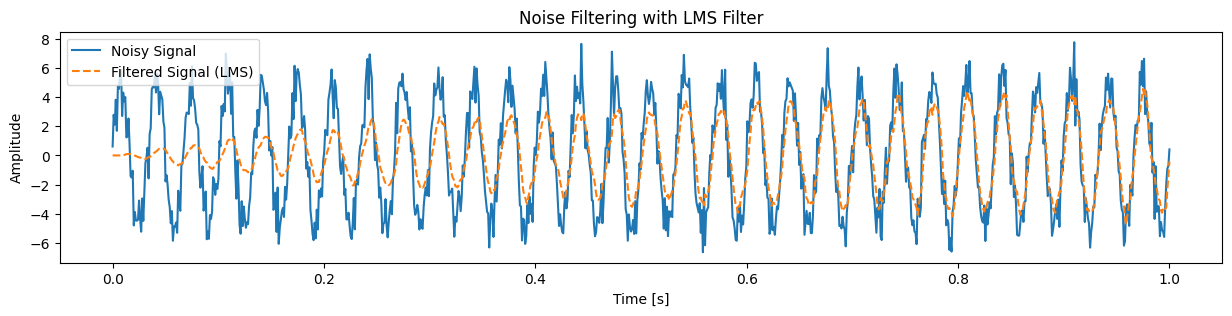

In [ ]:
# Apply LMS filter
mu = 0.00005  # Step size
order = 10  # Filter order
filtered_signal_lms = lms_filter(sine_signal_gaussian, mu, order)

# Plot the original and filtered signals
plt.figure(figsize=(15, 3))
plt.plot(t2, sine_signal_gaussian, label='Noisy Signal')
plt.plot(t2, filtered_signal_lms, label='Filtered Signal (LMS)', linestyle='--')
plt.title('Noise Filtering with LMS Filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [ ]:
filtered_1 = apply_highpass_filter(ecg_signal_all, cutoff=0.5, fs=1.5*sampling_rate)
filtered_1 = apply_notch_filter(filtered_1, cutoff=50, fs=sampling_rate, quality_factor=30)
x=filtered_1
filtered_1 = apply_moving_average_filter(filtered_1, window_size=9)
final=filtered_1

In [ ]:
filtered_2 = apply_wavelet_denoising(ecg_signal_all, wavelet='db4', level=2)
filtered_2 = apply_savgol_filter(filtered_2, window_length=11, polyorder=3)
filtered_2 = apply_highpass_filter(filtered_2, cutoff=0.5, fs=sampling_rate, order=5)

In [ ]:
filtered_3 = apply_notch_filter(ecg_signal_all, cutoff=50, fs=sampling_rate, quality_factor=30)
filtered_3 = apply_wavelet_denoising(filtered_3, wavelet='db4', level=1)
x = filtered_3
filtered_3 = apply_highpass_filter(filtered_3, cutoff=0.75, fs=sampling_rate)
final = filtered_3


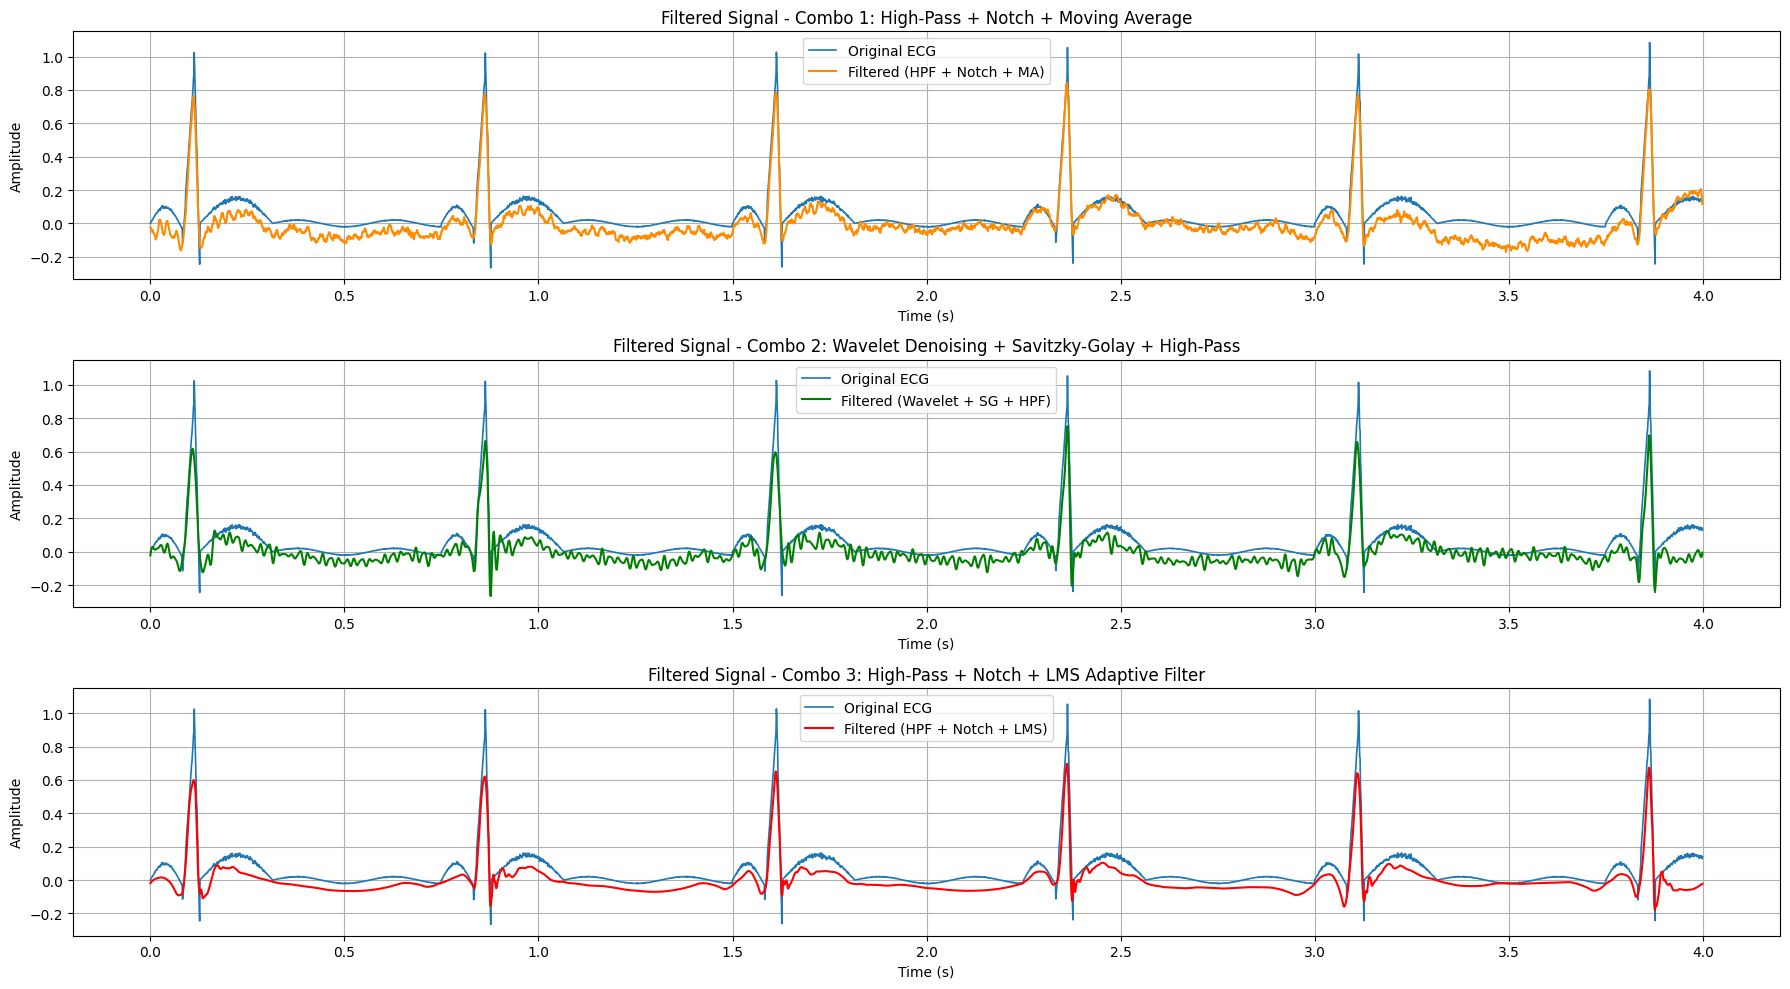

=== Mean Squared Error (MSE) for Each Filter Combination ===
Combo 1 (High-Pass + Notch + Moving Average)     MSE: 0.00524
Combo 2 (Wavelet Denoising + Savitzky-Golay + HPF) MSE: 0.00583
Combo 3 (High-Pass + Notch + LMS Adaptive)        MSE: 0.00535
SNR for Combo 1 (HPF + Notch + Moving Average): 6.17 dB
SNR for Combo 2 (Wavelet + SG + HPF): 5.70 dB
SNR for Combo 3 (HPF + Notch + LMS Adaptive): 6.08 dB


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- Plotting Filtered vs Original ECG ---

plt.figure(figsize=(18, 10))

plt.subplot(3, 1, 1)
plt.plot(t, ecg_signal, label='Original ECG', linewidth=1.2)
plt.plot(t, filtered_1, label='Filtered (HPF + Notch + MA)', color='darkorange')
plt.title('Filtered Signal - Combo 1: High-Pass + Notch + Moving Average')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, ecg_signal, label='Original ECG', linewidth=1.2)
plt.plot(t, filtered_2, label='Filtered (Wavelet + SG + HPF)', color='green')
plt.title('Filtered Signal - Combo 2: Wavelet Denoising + Savitzky-Golay + High-Pass')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, ecg_signal, label='Original ECG', linewidth=1.2)
plt.plot(t, filtered_3, label='Filtered (HPF + Notch + LMS)', color='red')
plt.title('Filtered Signal - Combo 3: High-Pass + Notch + LMS Adaptive Filter')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Calculating MSE for Each Filter Combination ---

mse_1 = mean_squared_error(ecg_signal, filtered_1)
mse_2 = mean_squared_error(ecg_signal, filtered_2)
mse_3 = mean_squared_error(ecg_signal, filtered_3)

print("=== Mean Squared Error (MSE) for Each Filter Combination ===")
print(f"Combo 1 (High-Pass + Notch + Moving Average)     MSE: {mse_1:.5f}")
print(f"Combo 2 (Wavelet Denoising + Savitzky-Golay + HPF) MSE: {mse_2:.5f}")
print(f"Combo 3 (High-Pass + Notch + LMS Adaptive)        MSE: {mse_3:.5f}")


import numpy as np

def calculate_snr(original, filtered):
    noise = original - filtered
    power_signal = np.mean(original ** 2)
    power_noise = np.mean(noise ** 2)
    snr = 10 * np.log10(power_signal / power_noise)
    return snr

snr_1 = calculate_snr(ecg_signal, filtered_1)
snr_2 = calculate_snr(ecg_signal, filtered_2)
snr_3 = calculate_snr(ecg_signal, filtered_3)

print(f"SNR for Combo 1 (HPF + Notch + Moving Average): {snr_1:.2f} dB")
print(f"SNR for Combo 2 (Wavelet + SG + HPF): {snr_2:.2f} dB")
print(f"SNR for Combo 3 (HPF + Notch + LMS Adaptive): {snr_3:.2f} dB")



## Combination of Filters (Plot Example)

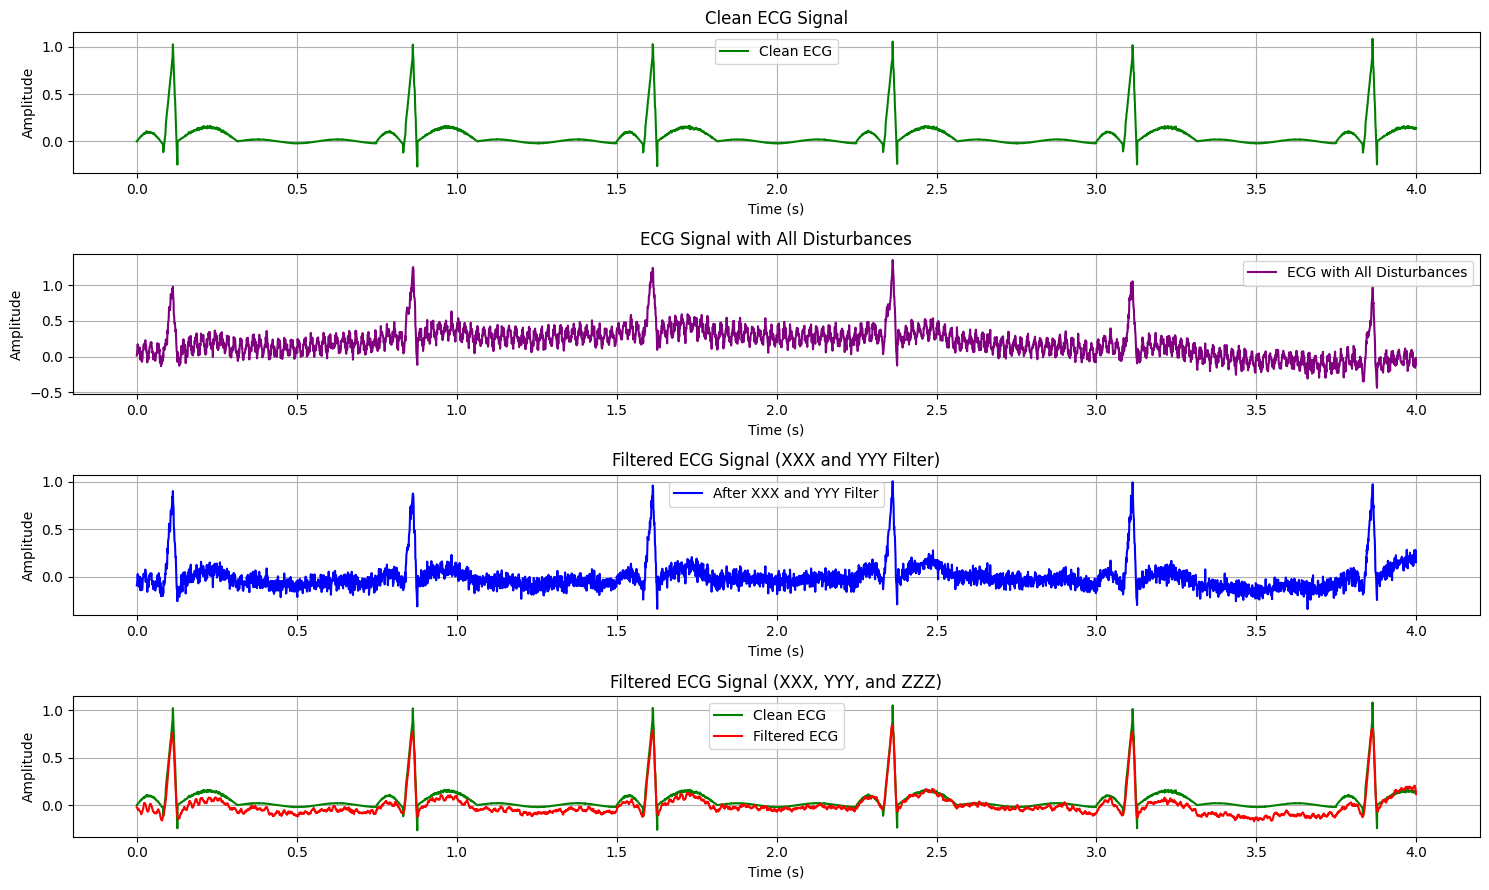

In [ ]:
# Apply XXX
dummy1 = ecg_signal_all
# Apply YYY
dummy2 = x
# Apply ZZZ
dummy3 = final

# Plot the signals
plt.figure(figsize=(15, 9))

plt.subplot(4, 1, 1)
plt.plot(t, ecg_signal, label='Clean ECG', color='green')
plt.title('Clean ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, ecg_signal_all, label='ECG with All Disturbances', color='purple')
plt.title('ECG Signal with All Disturbances')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, dummy2, label='After XXX and YYY Filter', color='blue')
plt.title('Filtered ECG Signal (XXX and YYY Filter)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t, ecg_signal, label='Clean ECG', color='green')
plt.plot(t, dummy3, label='Filtered ECG', color='red')
plt.title('Filtered ECG Signal (XXX, YYY, and ZZZ)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

